In [1]:
import sys
import json
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import pprint

project_root = Path.cwd().parent
sys.path.append(str(project_root))


## Load Sample Data

In [2]:
def load_clevr_samples(num_samples: int = 5):
    """Load random CLEVR samples with GT scene graphs."""
    random.seed(42)
    clevr_jsonl_path = project_root / "datasets" / "converted" / "clevr" / "clevr_val.jsonl"
    
    samples = []
    seen_ids = set()
    
    with open(clevr_jsonl_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            if data["image_id"] not in seen_ids:
                samples.append(data)
                seen_ids.add(data["image_id"])
            if len(samples) >= num_samples * 3:
                break
    
    return random.sample(samples, min(num_samples, len(samples)))

samples = load_clevr_samples(6)
print(f"Loaded {len(samples)} samples")
print(f"Sample keys: {list(samples[0].keys())}")

Loaded 6 samples
Sample keys: ['question_id', 'dataset', 'split', 'question', 'answer', 'image_path', 'image_id', 'scene_graph', 'program', 'metadata']


## Initialize Scene Graph Builder

In [3]:
from scene_graph.builder import SceneGraphBuilder
from scene_graph.relations import RelationConfig

# Configure relation thresholds
config = RelationConfig(
    horizontal_threshold=0.05,
    horizontal_hysteresis=0.02,
    depth_threshold=0.1,
    depth_hysteresis=0.03,
)

# Initialize builder (lazy initialization of perception components)
builder = SceneGraphBuilder(relation_config=config)
print("SceneGraphBuilder initialized (components will load on first use)")

SceneGraphBuilder initialized (components will load on first use)


## Build Scene Graph for Single Image

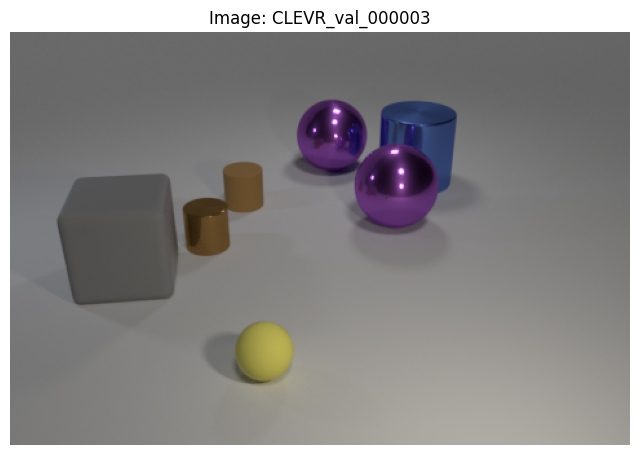

In [4]:
sample = samples[0]
image_path = project_root / sample["image_path"]

img = Image.open(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Image: {sample['image_id']}")
plt.axis('off')
plt.show()

In [5]:
detected_graph, intermediates = builder.build(
    image_path,
    use_segmentation=True,
    use_depth=True,
    use_heuristics=True,
    return_intermediates=True
)

print(f"Detected Scene Graph keys: {list(detected_graph.keys())}")
print(f"Number of objects: {len(detected_graph['objects'])}")
print(f"Relationships: {list(detected_graph['relationships'].keys())}")

SceneGraphBuilder: Initialized HybridDetector
SceneGraphBuilder: Initialized BoxSegmenter


Using cache found in C:\Users\bgdj2/.cache\torch\hub\intel-isl_MiDaS_master
c:\neurosymbolic-vqa\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\neurosymbolic-vqa\venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\bgdj2/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\bgdj2/.cache\torch\hub\intel-isl_MiDaS_master


SceneGraphBuilder: Initialized DepthEstimator
CLIP loaded and text embeddings cached!
SceneGraphBuilder: Initialized AttributeExtractor
Detected Scene Graph keys: ['objects', 'relationships']
Number of objects: 8
Relationships: ['left', 'right', 'front', 'behind']


## Visualize Scene Graph

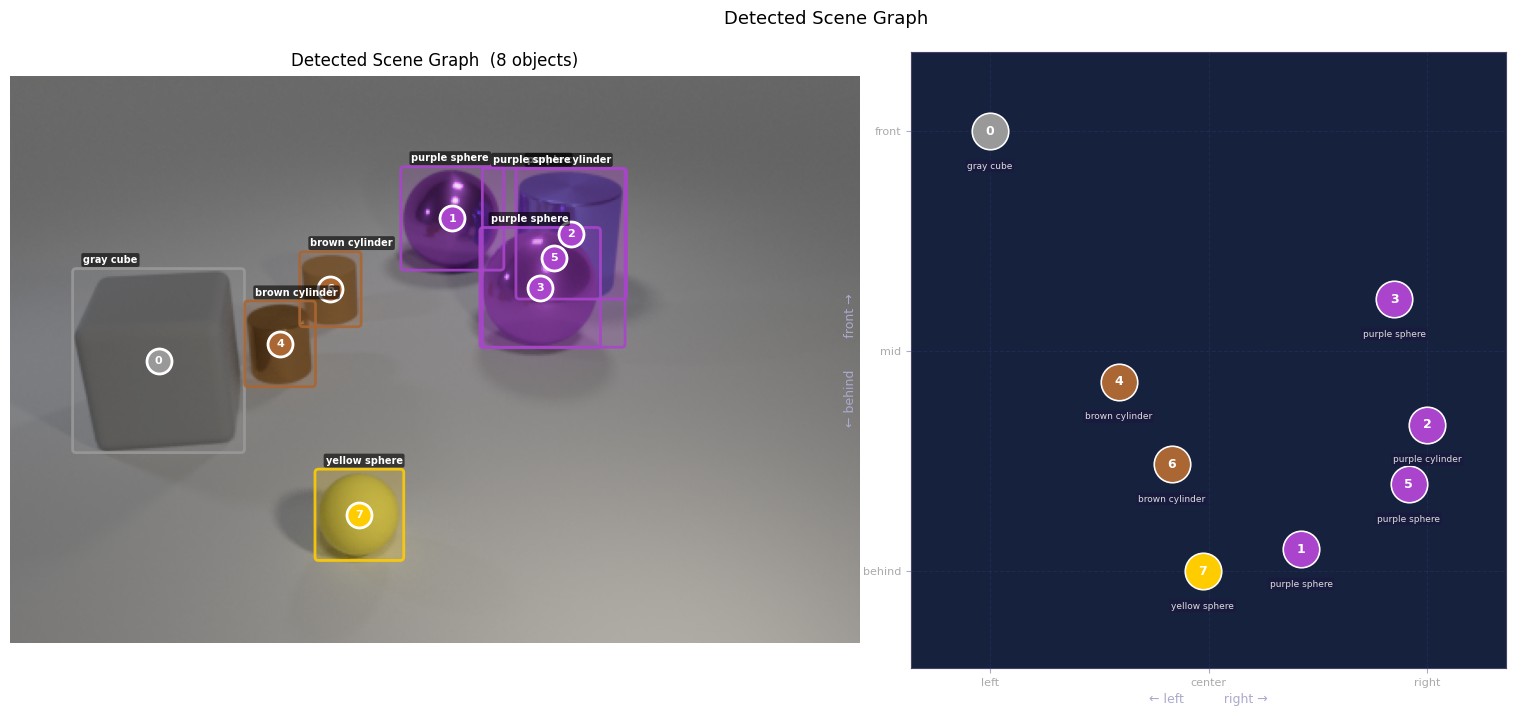

In [6]:
from scene_graph.renderer import render_scene_graph, compare_scene_graphs

fig = render_scene_graph(image_path, detected_graph, title="Detected Scene Graph")
plt.show()

## Compare Scene Graph Formats: GT vs Detected

In [7]:
gt_scene = sample['scene_graph']

# detected_graph is already in CLEVR format!
print("=" * 60)
print("CLEVR GT FORMAT:")
print("=" * 60)
pprint.pprint(gt_scene['objects'][:3])  # First 3 objects
print(f"\nRelationships keys: {list(gt_scene['relationships'].keys())}")

print("\n" + "=" * 60)
print("DETECTED (same CLEVR FORMAT):")
print("=" * 60)
pprint.pprint(detected_graph['objects'][:3])  # First 3 objects
print(f"\nRelationships keys: {list(detected_graph['relationships'].keys())}")

CLEVR GT FORMAT:
[{'3d_coords': [2.1417222023010254, -2.7576637268066406, 0.3499999940395355],
  'color': 'yellow',
  'material': 'rubber',
  'pixel_coords': [197, 247, 8.038165092468262],
  'rotation': 52.53684703422393,
  'shape': 'sphere',
  'size': 'small'},
 {'3d_coords': [-2.072401523590088, 2.136496067047119, 0.699999988079071],
  'color': 'purple',
  'material': 'metal',
  'pixel_coords': [249, 81, 13.48475170135498],
  'rotation': 277.821313290429,
  'shape': 'sphere',
  'size': 'large'},
 {'3d_coords': [-0.528790295124054, 2.905188798904419, 0.699999988079071],
  'color': 'blue',
  'material': 'metal',
  'pixel_coords': [315, 90, 12.911911010742188],
  'rotation': 77.97216669037716,
  'shape': 'cylinder',
  'size': 'large'}]

Relationships keys: ['right', 'behind', 'front', 'left']

DETECTED (same CLEVR FORMAT):
[{'bbox': [36.846954345703125,
           110.01278686523438,
           129.92410278320312,
           209.95858764648438],
  'color': 'gray',
  'material': 'rubber'

## Match Detected Objects to GT by Position

In [8]:
def match_objects_by_position(detected_objs, gt_objs, threshold=50):

    matches = []
    used_gt = set()
    
    for det_idx, det_obj in enumerate(detected_objs):
        det_cx, det_cy, _ = det_obj['pixel_coords']
        
        best_match = None
        best_dist = float('inf')
        
        for gt_idx, gt_obj in enumerate(gt_objs):
            if gt_idx in used_gt:
                continue
            gt_x, gt_y, _ = gt_obj['pixel_coords']
            
            dist = np.sqrt((det_cx - gt_x)**2 + (det_cy - gt_y)**2)
            if dist < best_dist and dist < threshold:
                best_dist = dist
                best_match = gt_idx
        
        if best_match is not None:
            matches.append((det_idx, best_match, best_dist))
            used_gt.add(best_match)
    
    return matches

matches = match_objects_by_position(detected_graph['objects'], gt_scene['objects'])

print(f"Matched {len(matches)} / {len(detected_graph['objects'])} detected objects to GT")
print(f"GT has {len(gt_scene['objects'])} objects\n")

print("MATCHES (det_idx -> gt_idx, distance):")
for det_idx, gt_idx, dist in matches:
    det_obj = detected_graph['objects'][det_idx]
    gt_obj = gt_scene['objects'][gt_idx]
    
    det_desc = f"{det_obj.get('size', '?')} {det_obj.get('color', '?')} {det_obj.get('shape', '?')}"
    gt_desc = f"{gt_obj['size']} {gt_obj['color']} {gt_obj['shape']}"
    
    match_symbol = "✓" if det_desc == gt_desc else "≠"
    print(f"  [{det_idx}] {det_desc:25} -> [{gt_idx}] {gt_desc:25} (dist={dist:.1f}px) {match_symbol}")

Matched 7 / 8 detected objects to GT
GT has 7 objects

MATCHES (det_idx -> gt_idx, distance):
  [0] large gray cube           -> [3] large gray cube           (dist=3.7px) ✓
  [1] small purple sphere       -> [1] large purple sphere       (dist=1.3px) ≠
  [2] large purple cylinder     -> [2] large blue cylinder       (dist=2.2px) ≠
  [3] large purple sphere       -> [5] large purple sphere       (dist=1.2px) ✓
  [4] small brown cylinder      -> [4] small brown cylinder      (dist=0.5px) ✓
  [6] small brown cylinder      -> [6] small brown cylinder      (dist=1.4px) ✓
  [7] small yellow sphere       -> [0] small yellow sphere       (dist=0.2px) ✓


## Visualize GT vs Detected Side-by-Side

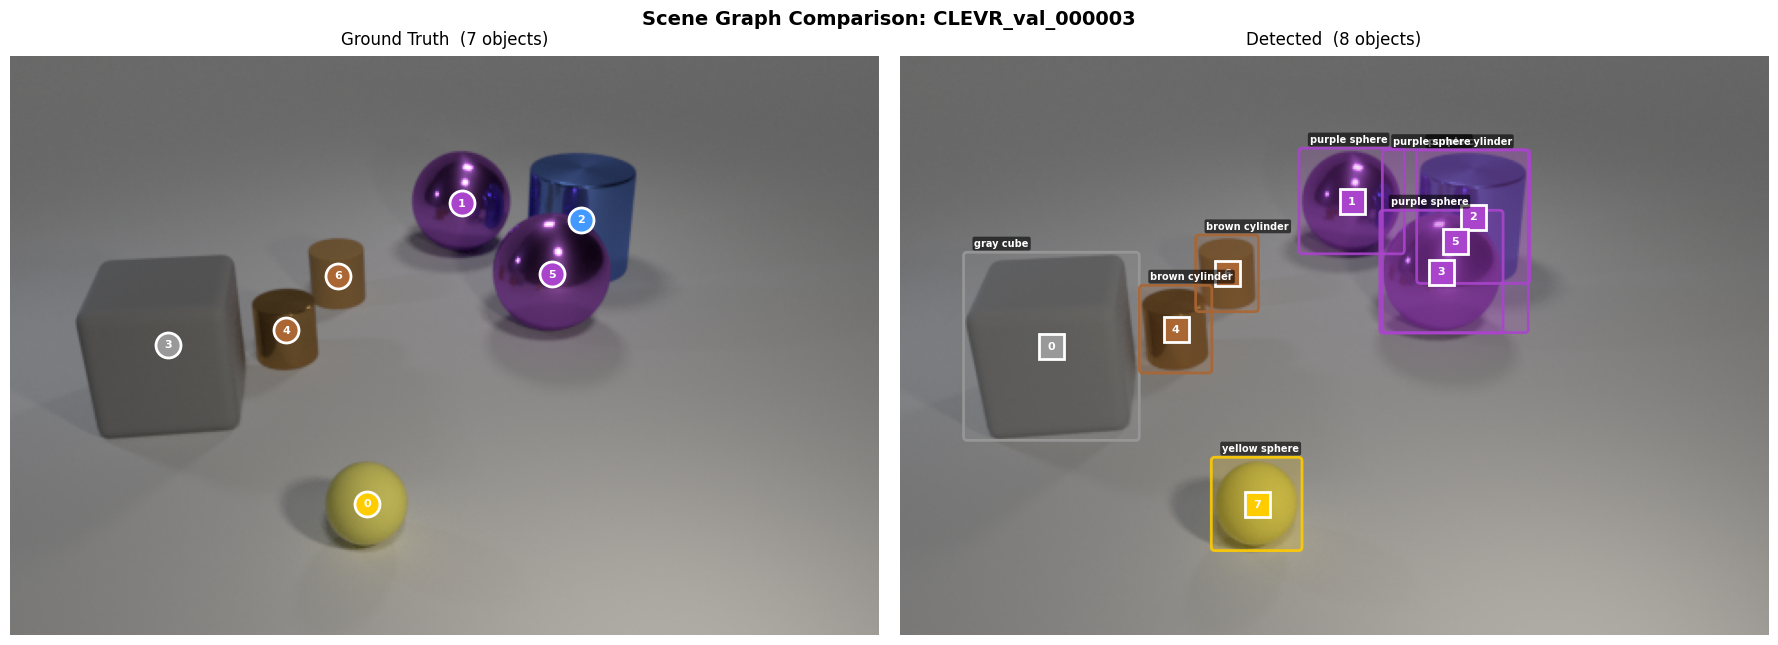

In [9]:
# Use the compare function from renderer
fig = compare_scene_graphs(image_path, gt_scene, detected_graph)
plt.suptitle(f"Scene Graph Comparison: {sample['image_id']}", fontsize=14, weight='bold')
plt.show()

## Attribute Accuracy for Matched Objects

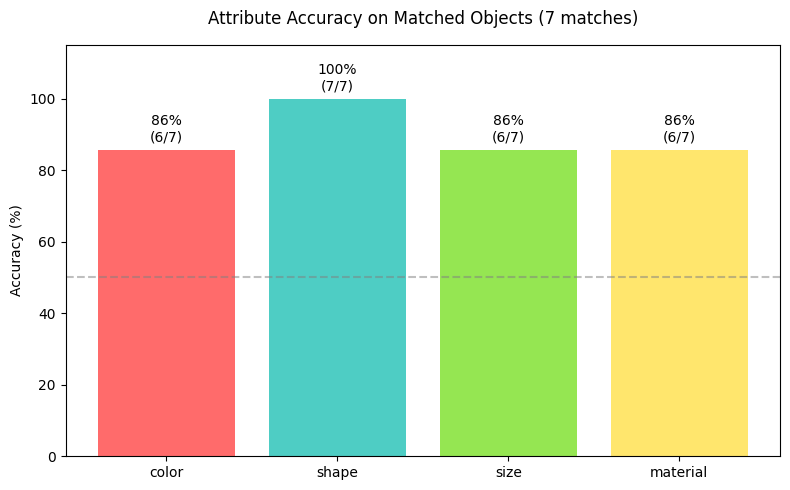

In [10]:
attr_correct = {'color': 0, 'shape': 0, 'size': 0, 'material': 0}
attr_total = {'color': 0, 'shape': 0, 'size': 0, 'material': 0}

for det_idx, gt_idx, _ in matches:
    det_obj = detected_graph['objects'][det_idx]
    gt_obj = gt_scene['objects'][gt_idx]
    
    for attr in ['color', 'shape', 'size', 'material']:
        if det_obj.get(attr) is not None:
            attr_total[attr] += 1
            if det_obj.get(attr) == gt_obj.get(attr):
                attr_correct[attr] += 1

attrs = list(attr_correct.keys())
accuracies = [
    attr_correct[a] / attr_total[a] * 100 if attr_total[a] > 0 else 0
    for a in attrs
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(attrs, accuracies, color=['#FF6B6B', '#4ECDC4', '#95E652', '#FFE66D'])

ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Attribute Accuracy on Matched Objects ({len(matches)} matches)', pad=15)
ax.set_ylim(0, 115)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

for bar, acc, corr, tot in zip(bars, accuracies, attr_correct.values(), attr_total.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{acc:.0f}%\n({corr}/{tot})',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Relation Comparison for Matched Objects

In [11]:
det_to_gt = {det_idx: gt_idx for det_idx, gt_idx, _ in matches}
gt_to_det = {gt_idx: det_idx for det_idx, gt_idx, _ in matches}

def compare_relations(det_rels, gt_rels, det_to_gt, gt_to_det):
    results = {}
    
    for rel_name in ['left', 'right', 'front', 'behind']:
        correct = 0
        total_det = 0
        total_gt = 0
        
        for det_idx, gt_idx in det_to_gt.items():
            det_related = set()
            for det_rel_idx in det_rels[rel_name][det_idx]:
                if det_rel_idx in det_to_gt:
                    det_related.add(det_to_gt[det_rel_idx])
            
            gt_related = set(gt_rels[rel_name][gt_idx])
            
            correct += len(det_related & gt_related)
            total_det += len(det_related)
            total_gt += len(gt_related)
        
        precision = correct / total_det * 100 if total_det > 0 else 0
        recall = correct / total_gt * 100 if total_gt > 0 else 0
        
        results[rel_name] = {'precision': precision, 'recall': recall, 
                            'correct': correct, 'det': total_det, 'gt': total_gt}
    
    return results

rel_comparison = compare_relations(
    detected_graph['relationships'], 
    gt_scene['relationships'],
    det_to_gt, gt_to_det
)

print("RELATION COMPARISON (for matched objects only):")
print("-" * 60)
for rel_name, stats in rel_comparison.items():
    print(f"{rel_name:8} | Precision: {stats['precision']:5.1f}% ({stats['correct']}/{stats['det']}) | "
          f"Recall: {stats['recall']:5.1f}% ({stats['correct']}/{stats['gt']})")

RELATION COMPARISON (for matched objects only):
------------------------------------------------------------
left     | Precision: 100.0% (18/18) | Recall:  85.7% (18/21)
right    | Precision: 100.0% (18/18) | Recall:  85.7% (18/21)
front    | Precision:  66.7% (12/18) | Recall:  57.1% (12/21)
behind   | Precision:  66.7% (12/18) | Recall:  57.1% (12/21)


## Summary

**`SceneGraphBuilder.build()`** now returns scene graph in CLEVR format directly (no intermediate classes):

```python
{
    'objects': [
        {'color': 'red', 'size': 'large', 'shape': 'cube', 'material': 'metal', 'pixel_coords': [x, y, depth]},
        ...
    ],
    'relationships': {
        'left': [[...], [...], ...],
        'right': [...],
        'front': [...],
        'behind': [...]
    }
}
```

Identical structure to CLEVR ground truth - enables direct comparison and DSL execution.